# Global End-to-End Anatomical Landmark Detection for Long-Leg Radiographs

This standalone notebook regresses global surgical keypoints across full-size radiograph images directly using a unified one-stage Conformer architecture, completely eliminating intermediate YOLO region-of-interest sub-cropping workflows.

## Imports & Configurations

Load necessary deep learning packages, configure environment paths to the internal Conformer Keypoint Detection head, and set global deterministic seeds and hyperparameter constants.

In [1]:
import os
import json
import random
import math
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

# Ensure CKD repository layer is accessible
sys.path.append(os.path.abspath("CKD"))
from models import Conformer_tiny_patch16_keypoint_half_heatmap, \
    Conformer_small_patch16_keypoint_half_heatmap, \
    Conformer_small_patch32_keypoint_half_heatmap, \
    Conformer_base_patch16_keypoint_half_heatmap
from utils import extract_coordinates

# Paths
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

# Global hyperparameter settings
SEED = 42
TARGET_SIZE = 768
HEATMAP_SCALE = 0.5
SIGMA = 6.0
KP_EPOCHS = 2_000
BATCH_SIZE = 4
LEARNING_RATE = 1e-4 * (HEATMAP_SCALE / 0.25)

# Model settings
MODEL_VARIANT = "small_p16"          # options: "tiny", "small_p16", "small_p32", "base"
CHECKPOINT_PATH = "best_model_global.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

# Map out dense multi-hemisphere keypoints
GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh", "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh", "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh"
]

LANDMARK_COLORS = {
    "femur_head_lh": "darkgreen", "knee_inner_lh": "darkblue", "ost_point_lh": "darkred", "knee_outer_lh": "darkviolet", "ankle_inner_lh": "darkorange", "ankle_outer_lh": "teal",
    "fujisawa_lh": "gold", "ankle_c_lh": "navy", "target_at_ankle_lh": "magenta",
    "femur_head_rh": "lightgreen", "knee_inner_rh": "lightblue", "ost_point_rh": "lightcoral", "knee_outer_rh": "plum", "ankle_inner_rh": "sandybrown", "ankle_outer_rh": "paleturquoise",
    "fujisawa_rh": "khaki", "ankle_c_rh": "slategray", "target_at_ankle_rh": "violet"
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

Hardware device registered: cuda


## GPU Availability Check
Validating hardware acceleration ensures efficiently trained computer vision models. Here we check the PyTorch version and query the presence and name of any available GPUs.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")

if gpu_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
GPU available: True
GPU Device Name: NVIDIA A100-SXM4-80GB


## Dynamic Full-Scale Dataset Architecture

We construct a PyTorch Dataset mapping multiple side annotations per radiograph into a single coherent 12-channel target structure, applying global letterbox adjustments to preserve spatial features natively.

In [3]:
def preprocess_global_image(img, target_size=512):
    orig_w, orig_h = img.size
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)

def apply_augmentation(pil_img, final_kps):
    import torchvision.transforms.functional as TF
    import numpy as np
    import cv2

    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size

    # 1. Brightness & contrast
    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))

    # 2. Gaussian noise
    if random.random() < 0.4:
        arr = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 12), arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)

    # 3. Gamma correction
    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = np.power(arr, gamma)
        img = Image.fromarray((arr * 255).astype(np.uint8))

    # 4. CLAHE
    if random.random() < 0.4:
        arr = np.array(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(arr[:, :, 0])
        arr = np.stack([processed, processed, processed], axis=2)
        img = Image.fromarray(arr)

    # 5. Sharpness
    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))

    # 6. Rotation ±10°
    if random.random() < 0.5:
        angle = random.uniform(-10, 10)
        img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy = W / 2.0, H / 2.0
        rad = math.radians(-angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0:
                continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0] = cos_a * dx - sin_a * dy + cx
            kp[1] = sin_a * dx + cos_a * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    # 7. Vertical shift ±15px
    if random.random() < 0.3:
        shift_y = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, shift_y), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0:
                continue
            kp[1] += shift_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    # 8. Scale jitter ±10%
    if random.random() < 0.3:
        scale_factor = random.uniform(0.90, 1.10)
        new_w = int(W * scale_factor)
        new_h = int(H * scale_factor)
        img = TF.resize(img, [new_h, new_w])
        if scale_factor < 1.0:
            pad_left = (W - new_w) // 2
            pad_top = (H - new_h) // 2
            padded = Image.new("RGB", (W, H), (0, 0, 0))
            padded.paste(img, (pad_left, pad_top))
            img = padded
            offset_x, offset_y = pad_left, pad_top
        else:
            crop_left = (new_w - W) // 2
            crop_top = (new_h - H) // 2
            img = TF.crop(img, crop_top, crop_left, H, W)
            offset_x, offset_y = -crop_left, -crop_top
        for kp in kps:
            if kp[0] < 0:
                continue
            kp[0] = kp[0] * scale_factor + offset_x
            kp[1] = kp[1] * scale_factor + offset_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    return img, kps

class GlobalRadiographKeypointDataset(Dataset):
    def __init__(self, coco_json_path, split="train", split_ratios=(0.8, 0.1, 0.1), target_size=512, heatmap_scale=0.25, sigma=2.0, seed=42):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        self.num_keypoints = 12
        self.split = split
        
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        images_info = {img["id"]: img for img in coco_data.get("images", [])}
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            img_id = ann.get("image_id")
            if img_id not in anns_by_img:
                anns_by_img[img_id] = []
            anns_by_img[img_id].append(ann)
            
        valid_samples = []
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info: continue
            img_info = images_info[img_id]
            img_w = img_info.get("width", 2860)
            
            kps_flat = [-1.0, -1.0, 0] * 12
            has_valid_kp = False
            
            for ann in anns:
                kps = ann.get("keypoints", [])
                if not kps: continue
                
                ann_bbox = ann.get("bbox", [0, 0, 0, 0])
                ann_cx = ann_bbox[0] + ann_bbox[2] / 2.0
                base = 0 if ann_cx < img_w / 2.0 else 6
                
                cat_id = ann.get("category_id")
                if cat_id == 1 and len(kps) >= 2:
                    kps_flat[base*3 : (base+1)*3] = [kps[0], kps[1], 2 if kps[0]>0 else 0]
                    if kps[0] > 0: has_valid_kp = True
                elif cat_id == 2 and len(kps) >= 9:
                    for k in range(3):
                        idx = base + 1 + k
                        kps_flat[idx*3 : (idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_valid_kp = True
                elif cat_id == 3 and len(kps) >= 6:
                    for k in range(2):
                        idx = base + 4 + k
                        kps_flat[idx*3 : (idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_valid_kp = True
                        
            if has_valid_kp:
                filename = img_info.get("file_name")
                img_dir = os.path.dirname(coco_json_path) if os.path.dirname(coco_json_path) else "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    if os.path.exists(os.path.join("/tf/data/hto/xrays", os.path.basename(filename))):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path": os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat
                })
                
        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)
        
        num_samples = len(valid_samples)
        train_end = int(num_samples * split_ratios[0])
        val_end = train_end + int(num_samples * split_ratios[1])
        
        if split == "train":
            self.samples = valid_samples[:train_end]
        elif split == "val":
            self.samples = valid_samples[train_end:val_end]
        elif split == "test":
            self.samples = valid_samples[val_end:]
        else:
            self.samples = valid_samples
            
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))
            
        processed_img, scale, padding = preprocess_global_image(img, self.target_size)
        
        final_kps = []
        kp_visibility = []
        
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_x = kp_x * scale + padding[0]
                final_y = kp_y * scale + padding[1]
                kp_visibility.append(1.0)
            else:
                final_x, final_y = -1.0, -1.0
                kp_visibility.append(0.0)
            final_kps.append([final_x, final_y])

        if self.split == "train":
            processed_img, final_kps = apply_augmentation(processed_img, final_kps)
            kp_visibility = [1.0 if final_kps[i][0] >= 0 else 0.0
                     for i in range(self.num_keypoints)]

        img_tensor = torch.from_numpy(np.array(processed_img)).permute(2, 0, 1).float() / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = (img_tensor - mean) / std
        
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        for i in range(self.num_keypoints):
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and final_kps[i][0] >= 0:
                kp_hm_x = final_kps[i][0] * self.heatmap_scale
                kp_hm_y = final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
                
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "visibility": torch.tensor(kp_visibility, dtype=torch.float32),
            "img_path": sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"])
        }

if os.path.exists(COCO_JSON_PATH):
    train_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="train", target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    val_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val", target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    test_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="test", target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    
    if len(train_ds) > 0: train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True,
                                                   persistent_workers=True, prefetch_factor=2)
    if len(val_ds) > 0: val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True,
                                               persistent_workers=True, prefetch_factor=2)
    if len(test_ds) > 0: test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True,
                                                 persistent_workers=True, prefetch_factor=2)
    print(f"Global datasets staged successfully: {len(train_ds)} Train, {len(val_ds)} Validation, {len(test_ds)} Test samples.")
else:
    print("Annotations missing; initialization pipeline suspended.")

Global datasets staged successfully: 43 Train, 5 Validation, 6 Test samples.


## Global Conformer Model Initialization & Training Loop

Set up the keypoint detector wrapper supervising all 12 targets simultaneously under Mean Squared Error (MSE) minimization.

Epoch 0001/2000 | Train: 0.249966 | Val: 0.258074 | NMSE: 0.198781 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 1.7% | PCK@0.05: 1.7%
Epoch 0002/2000 | Train: 0.225904 | Val: 0.241775 | NMSE: 0.139526 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 6.7%
Epoch 0003/2000 | Train: 0.214329 | Val: 0.223671 | NMSE: 0.177203 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 1.7%
Epoch 0004/2000 | Train: 0.206832 | Val: 0.207663 | NMSE: 0.567337 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0005/2000 | Train: 0.200419 | Val: 0.199190 | NMSE: 0.574093 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0006/2000 | Train: 0.194568 | Val: 0.192913 | NMSE: 0.513542 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0007/2000 | Train: 0.188534 | Val: 0.186605 | NMSE: 0.531077 | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0008/2000 | Train: 0.182581 | Val: 0.18087

/tmp/ipykernel_1171/1792379084.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_global.load_state_dict(torch.load(CHECKPOINT_PATH))


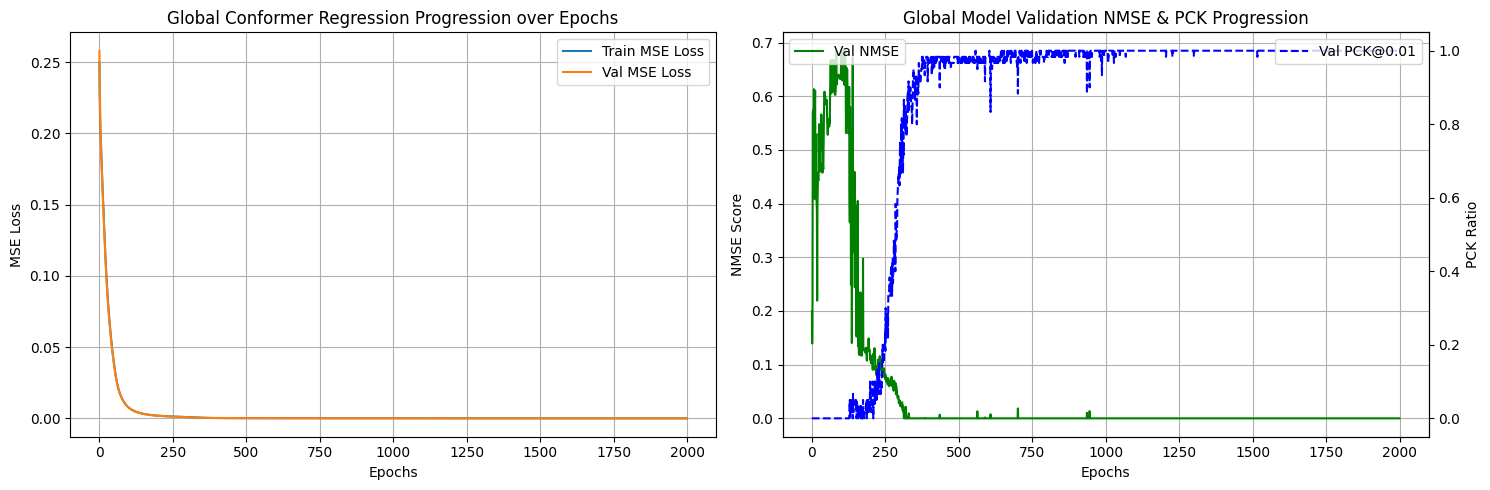

In [4]:
def masked_heatmap_loss(pred_hms, target_hms, visibility):
    """
    pred_hms:   (B, K, H, W)  — model output after sigmoid
    target_hms: (B, K, H, W)  — ground truth heatmaps
    visibility: (B, K)        — 1.0 if keypoint exists, 0.0 if not
    """
    # Expand visibility to match heatmap spatial dims: (B, K) → (B, K, 1, 1)
    mask = visibility.unsqueeze(-1).unsqueeze(-1)

    # Zero out loss on invisible keypoint channels
    diff = (pred_hms - target_hms) ** 2
    masked_diff = diff * mask

    # Average only over valid keypoints (avoid dividing by zero)
    H, W = pred_hms.shape[-2], pred_hms.shape[-1]
    n_valid = mask.sum().clamp(min=1)
    return masked_diff.sum() / (n_valid * H * W)

_model_map = {
    "tiny": Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base": Conformer_base_patch16_keypoint_half_heatmap,
}
model_global = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
optimizer_global = optim.AdamW(model_global.parameters(), lr=LEARNING_RATE)
scheduler_global = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_global, T_max=KP_EPOCHS, eta_min=1e-6)

def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Computes Percentage of Correct Keypoints (PCK) over active global target points."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask):
        return 0.0
    dists = torch.norm(preds - gts, dim=-1)
    correct = dists < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()

def calculate_nmse(preds, gts, normalize_by=512):
    """Computes Normalized Mean Squared Error over active global target points."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask):
        return 0.0
    diff = preds - gts
    mse = torch.mean(torch.sum(diff ** 2, dim=-1)[valid_mask])
    return (mse / (normalize_by ** 2)).item()

def train_global_routine(model, t_loader, v_loader, opt, scheduler, epochs, dev):
    t_losses, v_losses, v_nmses, v_pcks = [], [], [], []
    best_val_loss = float('inf')
    best_nmse = float('inf')
    for e in range(epochs):
        model.train()
        e_loss = 0.0
        for batch in t_loader:
            imgs, target_hms, visibility = batch["image"].to(dev), batch["heatmap"].to(dev), batch["visibility"].to(dev)
            opt.zero_grad()
            pred_hms = torch.sigmoid(model(imgs))
            loss = masked_heatmap_loss(pred_hms, target_hms, visibility)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            e_loss += loss.item()

        scheduler.step()
            
        t_l = e_loss / len(t_loader)
        t_losses.append(t_l)
        
        model.eval()
        v_loss = 0.0
        epoch_preds, epoch_gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, target_hms, visibility, gts = batch["image"].to(dev), batch["heatmap"].to(dev), batch["visibility"].to(dev), batch["keypoint"]
                pred_hms = torch.sigmoid(model(imgs))
                v_loss += masked_heatmap_loss(pred_hms, target_hms, visibility).item()
                
                coords = extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE)
                epoch_preds.append(coords)
                epoch_gts.append(gts)
                
        v_l = v_loss / len(v_loader)
        v_losses.append(v_l)
        
        preds_cat = torch.cat(epoch_preds, dim=0)
        gts_cat = torch.cat(epoch_gts, dim=0)
        
        nmse_val = calculate_nmse(preds_cat, gts_cat, normalize_by=TARGET_SIZE)

        if nmse_val < best_nmse:
            best_nmse = nmse_val
            torch.save(model.state_dict(), CHECKPOINT_PATH)
        
        pck_vals = {t: calculate_pck(preds_cat, gts_cat, threshold=t, normalize_by=TARGET_SIZE)
            for t in [0.005, 0.01, 0.02, 0.05]}
        pck_val = pck_vals[0.01]
        
        v_nmses.append(nmse_val)
        v_pcks.append(pck_val)
        
        print(f"Epoch {e+1:04d}/{epochs} | Train: {t_l:.6f} | Val: {v_l:.6f} | NMSE: {nmse_val:.6f} | PCK@0.005: {pck_vals[0.005]*100:.1f}% | PCK@0.01: {pck_vals[0.01]*100:.1f}% | PCK@0.02: {pck_vals[0.02]*100:.1f}% | PCK@0.05: {pck_vals[0.05]*100:.1f}%")
    return t_losses, v_losses, v_nmses, v_pcks

if 'train_loader' in locals():
    # run once before training to sanity-check loss scale
    model_global.train()
    batch = next(iter(train_loader))
    imgs, target_hms = batch["image"].to(device), batch["heatmap"].to(device)
    
    train_losses, val_losses, val_nmses, val_pcks = train_global_routine(model_global, train_loader, val_loader, optimizer_global, scheduler_global, KP_EPOCHS, device)
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH))
    print(f"Loaded best checkpoint from {CHECKPOINT_PATH}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label="Train MSE Loss")
    ax1.plot(val_losses, label="Val MSE Loss")
    ax1.set_title("Global Conformer Regression Progression over Epochs")
    ax1.set_xlabel("Epochs"), ax1.set_ylabel("MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2.set_xlabel("Epochs"), ax2.set_ylabel("NMSE Score")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.01", color="blue", linestyle="--")
    ax2_pck.set_ylabel("PCK Ratio")
    ax2.set_title("Global Model Validation NMSE & PCK Progression")
    ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Training logic uncalled in un-executed source schema.")

## Surgical Correction Angle Analytics & Visual Inference

Map predicted output channels directly back to global radiograph scaling, extract endpoints to evaluate Left and Right surgical geometries independently via vector `atan2` formulas, draw spatial distributions, and trace comparative bi-hemisphere overlay diagrams.


GLOBAL ARCHITECTURE PERFORMANCE SUMMARY
Total Evaluated Hemisphere Cases: 11 (5 left, 6 right)
Mean Absolute Error (all):        0.3391°
Mean Absolute Error (left hemi):  0.2630°
Mean Absolute Error (right hemi): 0.4026°
Max Absolute Error (all):         1.0233°
Error Std Dev (all):              0.4418°


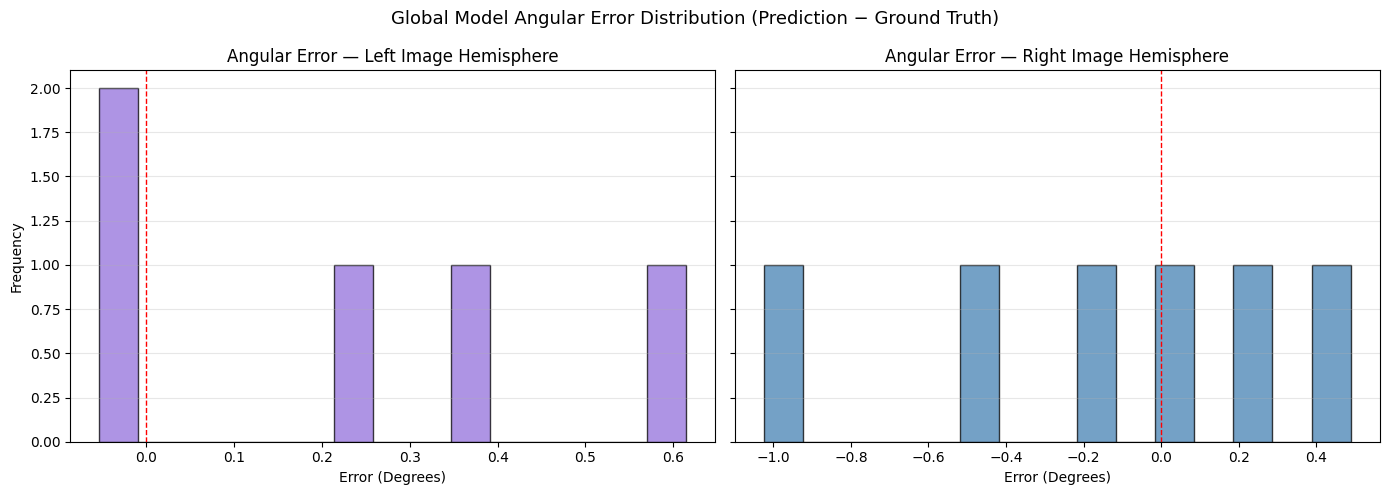

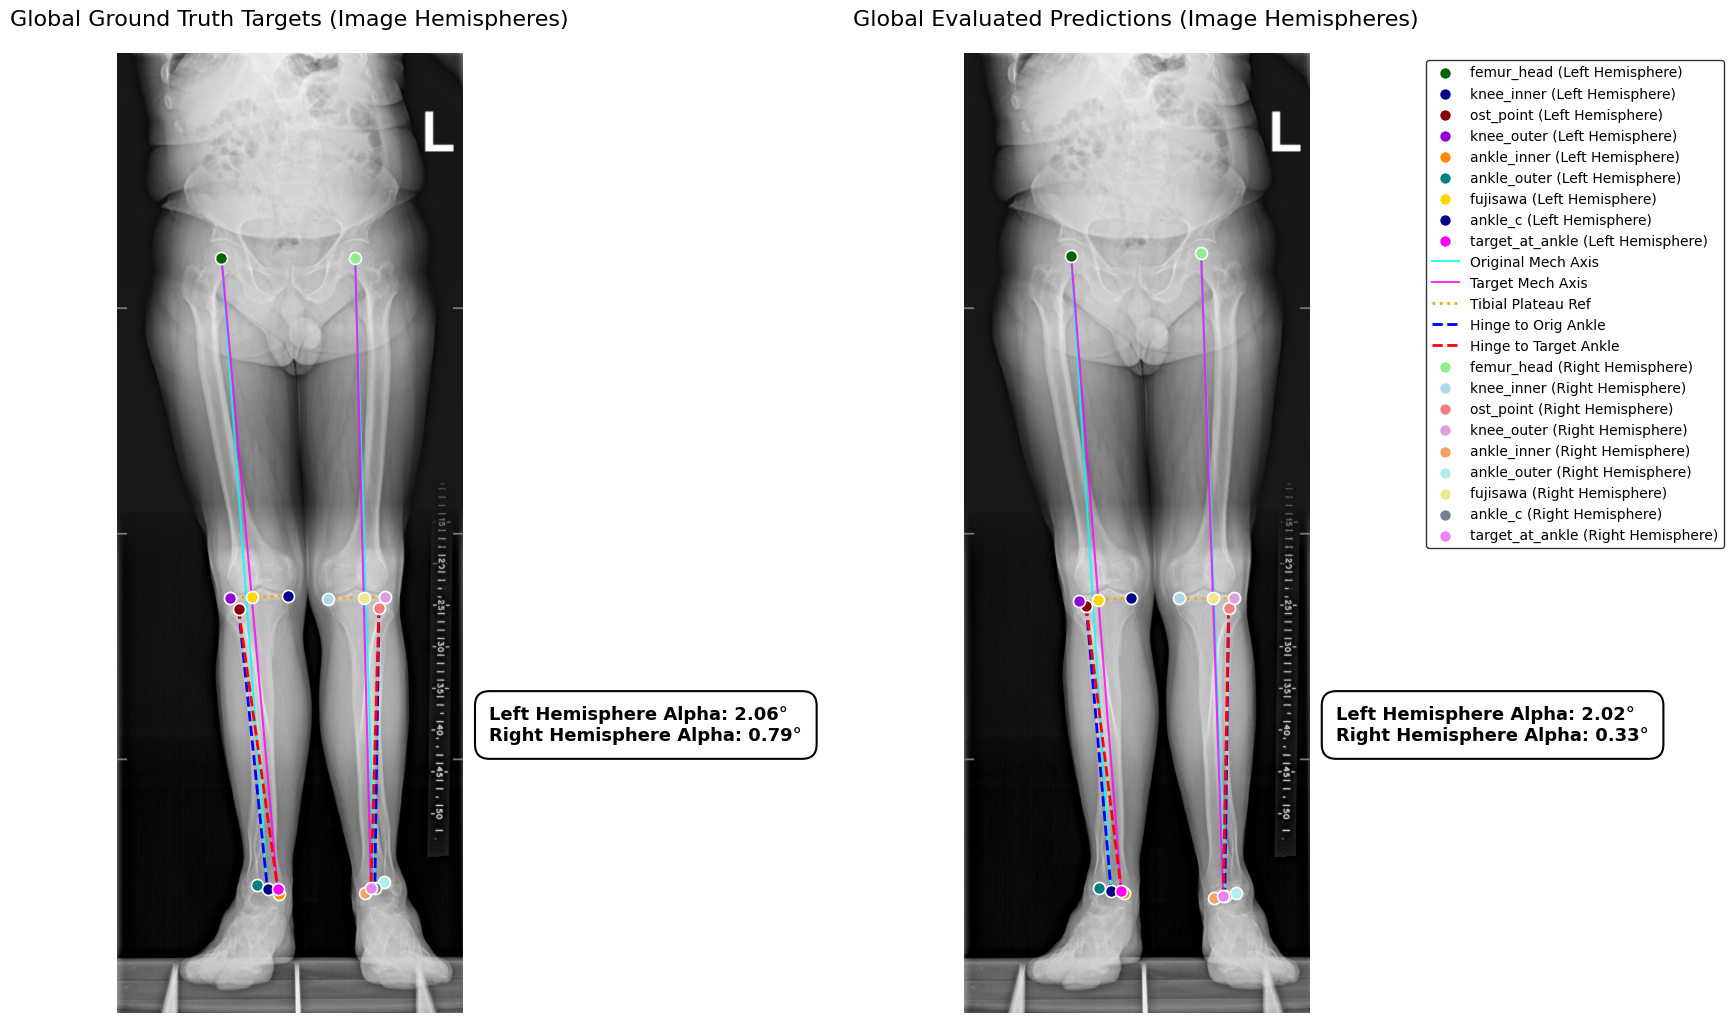

Successfully traced layout map for file: 59_0.png


In [5]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    orig_w, orig_h = orig_size
    scale = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top = (target_size - int(orig_h * scale)) // 2
    orig_x = (kp_final[0] - pad_left) / scale
    orig_y = (kp_final[1] - pad_top) / scale
    return np.array([orig_x, orig_y])

def calculate_intersection(p1, p2, target_y):
    if p2[0] == p1[0]:
        return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        if abs(target_y - p1[1]) < 1e-9:
            return p1[0]   # degenerate: line lies on target_y, pick p1
        return float('nan')  # no intersection; callers should guard for nan
    return (target_y - p1[1]) / m + p1[0]

def evaluate_side_geometry(points):
    """Computes Fujisawa point and true correction angle Alpha via the Miniaci method."""
    ankle_c = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    ankle_y = ankle_c[1]

    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])

    target_intersect_x = calculate_intersection(points["femur_head"], fujisawa, ankle_y)
    target_at_ankle = np.array([target_intersect_x, ankle_y])

    v_orig_ankle = ankle_c - points["ost_point"]
    theta_orig = math.atan2(v_orig_ankle[1], v_orig_ankle[0])

    v_target_ankle = target_at_ankle - points["ost_point"]
    theta_target = math.atan2(v_target_ankle[1], v_target_ankle[0])

    raw = abs(theta_orig - theta_target)
    alpha = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle

if 'test_loader' in locals():
    model_global.eval()
    global_results = []

    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["image"].to(device)
            pred_hms = torch.sigmoid(model_global(imgs))
            coords_batch = extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE).numpy()
            gts_batch = batch["keypoint"].numpy()
            paths_batch = batch["img_path"]
            orig_sizes = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c = coords_batch[b]
                gt_c = gts_batch[b]
                path_b = paths_batch[b]

                pred_pts_l, pred_pts_r = {}, {}
                gt_pts_l, gt_pts_r = {}, {}

                side_keys = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
                for idx_k, name_k in enumerate(side_keys):
                    # Left Side decoding
                    if gt_c[idx_k][0] >= 0:
                        gt_pts_l[name_k] = map_global_to_orig(gt_c[idx_k], orig_shape, TARGET_SIZE)
                        pred_pts_l[name_k] = map_global_to_orig(pred_c[idx_k], orig_shape, TARGET_SIZE)
                    # Right Side decoding
                    r_slot = idx_k + 6
                    if gt_c[r_slot][0] >= 0:
                        gt_pts_r[name_k] = map_global_to_orig(gt_c[r_slot], orig_shape, TARGET_SIZE)
                        pred_pts_r[name_k] = map_global_to_orig(pred_c[r_slot], orig_shape, TARGET_SIZE)

                res_l, res_r = None, None
                req_keys = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
                if all(k in gt_pts_l for k in req_keys) and all(k in pred_pts_l for k in req_keys):
                    gt_alpha, gt_fuji, gt_ank, gt_targ = evaluate_side_geometry(gt_pts_l)
                    pred_alpha, p_fuji, p_ank, p_targ = evaluate_side_geometry(pred_pts_l)
                    gt_pts_l["fujisawa"] = gt_fuji
                    gt_pts_l["ankle_c"] = gt_ank
                    gt_pts_l["target_at_ankle"] = gt_targ

                    pred_pts_l["fujisawa"] = p_fuji
                    pred_pts_l["ankle_c"] = p_ank
                    pred_pts_l["target_at_ankle"] = p_targ
                    res_l = {"side": "Left Image Hemisphere", "gt_angle": gt_alpha, "pred_angle": pred_alpha, "gt_pts": gt_pts_l, "pred_pts": pred_pts_l}

                if all(k in gt_pts_r for k in req_keys) and all(k in pred_pts_r for k in req_keys):
                    gt_alpha, gt_fuji, gt_ank, gt_targ = evaluate_side_geometry(gt_pts_r)
                    pred_alpha, p_fuji, p_ank, p_targ = evaluate_side_geometry(pred_pts_r)
                    gt_pts_r["fujisawa"] = gt_fuji
                    gt_pts_r["ankle_c"] = gt_ank
                    gt_pts_r["target_at_ankle"] = gt_targ

                    pred_pts_r["fujisawa"] = p_fuji
                    pred_pts_r["ankle_c"] = p_ank
                    pred_pts_r["target_at_ankle"] = p_targ
                    res_r = {"side": "Right Image Hemisphere", "gt_angle": gt_alpha, "pred_angle": pred_alpha, "gt_pts": gt_pts_r, "pred_pts": pred_pts_r}

                if res_l or res_r:
                    global_results.append({"img_path": path_b, "filename": os.path.basename(path_b), "res_l": res_l, "res_r": res_r})

    # Evaluation histogram plotting
    # Each item has res_l (left image hemisphere) and res_r (right image hemisphere).
    # Errors are computed per hemisphere: pred_angle - gt_angle on the same image side.
    all_errors_lh = []
    all_errors_rh = []
    for item in global_results:
        if item["res_l"]: all_errors_lh.append(item["res_l"]["pred_angle"] - item["res_l"]["gt_angle"])
        if item["res_r"]: all_errors_rh.append(item["res_r"]["pred_angle"] - item["res_r"]["gt_angle"])
    all_errors = all_errors_lh + all_errors_rh

    if all_errors:
        print("\n" + "="*50)
        print("GLOBAL ARCHITECTURE PERFORMANCE SUMMARY")
        print("="*50)
        print(f"Total Evaluated Hemisphere Cases: {len(all_errors)} ({len(all_errors_lh)} left, {len(all_errors_rh)} right)")
        print(f"Mean Absolute Error (all):        {np.mean([abs(e) for e in all_errors]):.4f}°")
        print(f"Mean Absolute Error (left hemi):  {np.mean([abs(e) for e in all_errors_lh]):.4f}°" if all_errors_lh else "Mean Absolute Error (left hemi):  N/A")
        print(f"Mean Absolute Error (right hemi): {np.mean([abs(e) for e in all_errors_rh]):.4f}°" if all_errors_rh else "Mean Absolute Error (right hemi): N/A")
        print(f"Max Absolute Error (all):         {np.max([abs(e) for e in all_errors]):.4f}°")
        print(f"Error Std Dev (all):              {np.std(all_errors):.4f}°")
        print("="*50)

        fig, (ax_lh, ax_rh) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        for ax, errors, label, color in [
            (ax_lh, all_errors_lh, "Left Image Hemisphere", "mediumpurple"),
            (ax_rh, all_errors_rh, "Right Image Hemisphere", "steelblue"),
        ]:
            if errors:
                ax.hist(errors, bins=15, color=color, edgecolor='black', alpha=0.75)
                ax.axvline(0, color='red', linestyle='dashed', linewidth=1)
                ax.set_title(f"Angular Error — {label}")
                ax.set_xlabel("Error (Degrees)")
                ax.grid(True, axis='y', alpha=0.3)
            else:
                ax.set_visible(False)
        ax_lh.set_ylabel("Frequency")
        fig.suptitle("Global Model Angular Error Distribution (Prediction − Ground Truth)", fontsize=13)
        plt.tight_layout()
        plt.show()

    # Visual overlay side-by-side traces
    if global_results:
        sample_entry = random.choice([s for s in global_results if s["res_l"] and s["res_r"]]) if any(s["res_l"] and s["res_r"] for s in global_results) else random.choice(global_results)
        img_target = Image.open(sample_entry["img_path"]).convert("RGB")

        fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(22, 12))
        def draw_overlay(ax, data_item, is_gt=True):
            alpha_l = data_item["res_l"]["gt_angle" if is_gt else "pred_angle"] if data_item.get("res_l") else None
            alpha_r = data_item["res_r"]["gt_angle" if is_gt else "pred_angle"] if data_item.get("res_r") else None

            title_base = "Global Ground Truth Targets (Image Hemispheres)" if is_gt else "Global Evaluated Predictions (Image Hemispheres)"
            ax.imshow(img_target, cmap="gray")
            ax.set_title(title_base, fontsize=16, pad=20)

            angle_texts = []
            if alpha_l is not None:
                angle_texts.append(f"Left Hemisphere Alpha: {alpha_l:.2f}°")
            if alpha_r is not None:
                angle_texts.append(f"Right Hemisphere Alpha: {alpha_r:.2f}°")
            if angle_texts:
                box_text = "\n".join(angle_texts)
                ax.text(1.08, 0.3, box_text, transform=ax.transAxes, ha='left', va='center', fontsize=13, weight='bold', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.8', linewidth=1.5))

            for s_tag in ["res_l", "res_r"]:
                side_data = data_item[s_tag]
                if not side_data: continue

                pts = side_data["gt_pts"] if is_gt else side_data["pred_pts"]
                side_name = "Left Hemisphere" if s_tag == "res_l" else "Right Hemisphere"
                suffix = "_lh" if s_tag == "res_l" else "_rh"

                for k_name, coord in pts.items():
                    if isinstance(coord, np.ndarray) and coord.shape == (2,):
                        color_mapped = LANDMARK_COLORS.get(f"{k_name}{suffix}", "magenta")
                        label_str = f"{k_name} ({side_name})"
                        ax.scatter(coord[0], coord[1], s=75, color=color_mapped, edgecolors='white', linewidths=1.2, zorder=5, label=label_str)

                # 1. Original Mechanical Axis: femur_head to ankle_c
                ax.plot([pts["femur_head"][0], pts["ankle_c"][0]], [pts["femur_head"][1], pts["ankle_c"][1]], color='cyan', linestyle='-', linewidth=1.5, alpha=0.8, zorder=2, label="Original Mech Axis")

                # 2. Target Mechanical Axis: femur_head to target_at_ankle
                ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]], [pts["femur_head"][1], pts["target_at_ankle"][1]], color='magenta', linestyle='-', linewidth=1.5, alpha=0.8, zorder=3, label="Target Mech Axis")

                # 3. Tibial Plateau Reference Line
                ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]], [pts["knee_inner"][1], pts["knee_outer"][1]], color='orange', linestyle=':', linewidth=2, zorder=4, label="Tibial Plateau Ref")

                # 4. Miniaci Hinge Correction Arc Lines (The Wedge)
                ax.plot([pts["ost_point"][0], pts["ankle_c"][0]], [pts["ost_point"][1], pts["ankle_c"][1]], color='blue', linestyle='--', linewidth=2, zorder=4, label="Hinge to Orig Ankle")
                ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]], [pts["ost_point"][1], pts["target_at_ankle"][1]], color='red', linestyle='--', linewidth=2, zorder=4, label="Hinge to Target Ankle")

            ax.axis("off")
            if not is_gt:
                handles, labels = ax.get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                if by_label: ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.32, 1.0), loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='black')

        draw_overlay(ax_gt, sample_entry, is_gt=True)
        draw_overlay(ax_pred, sample_entry, is_gt=False)
        plt.subplots_adjust(left=0.05, bottom=0.1, top=0.9, wspace=0.35, right=0.72)
        plt.show()
        print(f"Successfully traced layout map for file: {sample_entry['filename']}")
else:
    print("Pipeline operations skipped seamlessly in un-executed context loop.")